# crossmatch_figures.ipynb

Regenerates publication figures from `HETDEX_PDR1_satellites.fits`.
Figures are saved to `figures/`; the diagnostic match gallery goes to `crossmatch/trend_plots/`.

Re-run any figure cell after editing `satstreak_plots.py` — no kernel restart needed.

In [1]:
%matplotlib inline
import importlib
import os, sys
import numpy as np
from astropy.table import Table

sys.path.insert(0, os.path.join(os.path.abspath("."), "crossmatch"))
import satstreak_plots as P

# Final publication catalog — same directory as this notebook
CATALOG     = "HETDEX_PDR1_satellites.fits"
FIGURES_DIR = "figures/"

In [2]:
pub = Table.read(CATALOG)

# The publication table uses short MRT column names; rename to what summary_panel expects.
pub.rename_columns(
    ["MJDx",        "Class",       "Height",       "Range",    "ginst",      "PA"],
    ["crossing_mjd","orbit_class","sat_height_km","range_km","g_mag_inst","streak_pa_sph_deg"],
)

# 'matched' is implicit: identification columns are masked for unmatched rows.
pub["matched"] = ~np.asarray(pub["NORAD"].mask
                              if hasattr(pub["NORAD"], "mask")
                              else np.zeros(len(pub), bool))

m = pub[pub["matched"]]
print(f"{len(pub)} total streaks, {len(m)} matched")

527 total streaks, 468 matched


In [6]:
# Load ifu-index to get survey shot MJDs (needed for streak-rate overlay in summary panel).
# shotid encodes YYYYMMDDNNN; parse the date portion to MJD.
from astropy.table import Table as _Table
from astropy.time import Time as _Time
import numpy as _np

_IFU_INDEX = os.path.join(os.path.dirname(os.path.abspath(CATALOG)),
                          "..", "..", "..", "ifu-index.fits")
if not os.path.exists(_IFU_INDEX):
    # Fallback: standard pdr1 mount point on JupyterHub
    _IFU_INDEX = "/home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/ifu-index.fits"
if not os.path.exists(_IFU_INDEX):
    _IFU_INDEX = "/home/jovyan/work/pdr1/ifu-index.fits"

_ifu = _Table.read(_IFU_INDEX)
_unique_shotids = _np.unique(_np.asarray(_ifu["shotid"], dtype=int))

def _shotid_to_mjd(shotids):
    s = _np.asarray(shotids, dtype=int)
    d = s // 1000
    iso = [f"{d_//10000:04d}-{(d_%10000)//100:02d}-{d_%100:02d}" for d_ in d]
    return _Time(iso, format="iso", scale="utc").mjd

shot_mjd = _shotid_to_mjd(_unique_shotids)
print(f"Survey shots loaded: {len(shot_mjd):,}  ({P.mjd_to_year(shot_mjd.min()):.2f} – {P.mjd_to_year(shot_mjd.max()):.2f})")

Survey shots loaded: 6,778  (2017.01 – 2024.58)


saved: figures/match_summary_panel.png


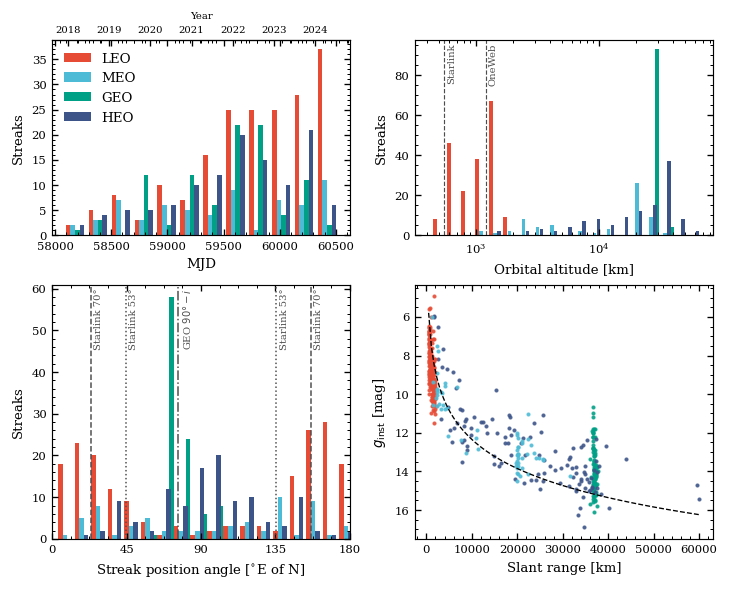

In [3]:
importlib.reload(P)
P.apjl_style()

fig = P.summary_panel(m)
print("saved:", P.save(fig, "match_summary_panel", plot_dir=FIGURES_DIR))

## Orbital-class spectra

Stacked normalised spectra for each orbit class.  Normalisation is to unit
median flux at 4500–5200 Å, so the panels compare reflectance *shape*.
The inset bar chart shows median instantaneous g magnitude per class
(inverted axis: brighter at top) to restore the brightness context that
normalisation removes.

/home/jovyan/work/pdr1/claude-tests/satellites/hetdex_sats/crossmatch/satstreak_spectra.py:142: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(np.where(good, f, np.nan), axis=0)
/home/jovyan/work/pdr1/claude-tests/satellites/hetdex_sats/crossmatch/satstreak_spectra.py:143: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(np.where(good, f, np.nan) - med), axis=0)
/home/jovyan/work/pdr1/claude-tests/satellites/hetdex_sats/crossmatch/satstreak_spectra.py:157: RuntimeWarning: All-NaN slice encountered
  out = np.nanmedian(np.where(good, f, np.nan), axis=0)


/opt/conda/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


saved: figures/orbit_class_spectra.png


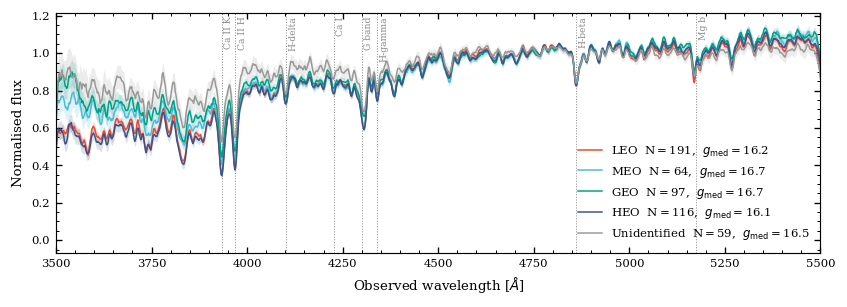

In [4]:
importlib.reload(P)
P.apjl_style()

fig = P.plot_orbit_spectra(pub, CATALOG)
print("saved:", P.save(fig, "orbit_class_spectra", plot_dir=FIGURES_DIR))

saved: figures/crossmatch_summary_panel.png


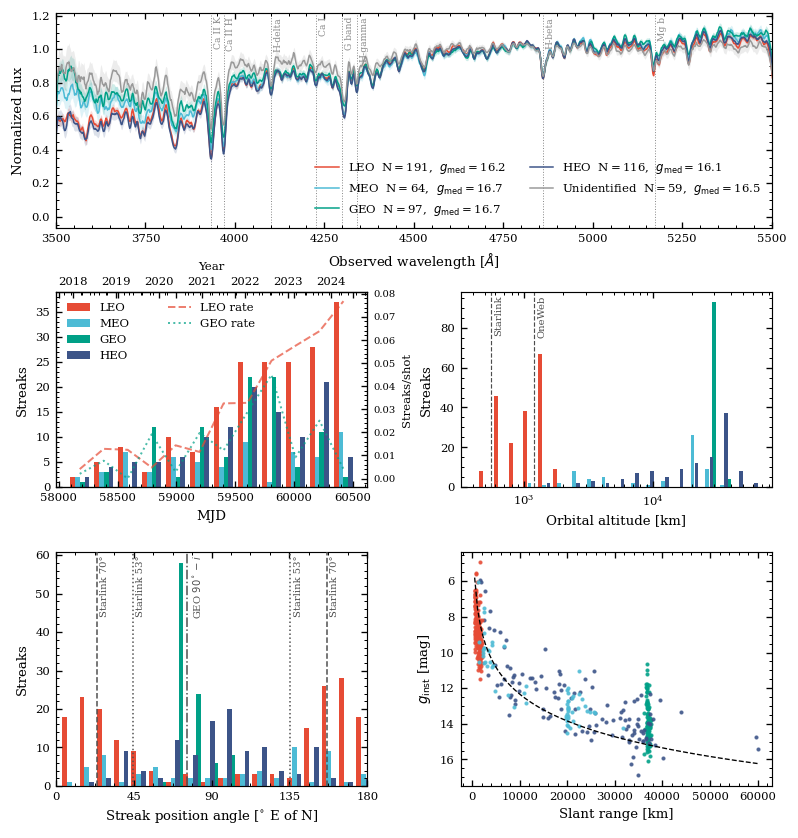

In [11]:
importlib.reload(P)
P.apjl_style()

fig = P.full_summary_panel(m, pub, CATALOG, shot_mjd=shot_mjd)
print("saved:", P.save(fig, "crossmatch_summary_panel", plot_dir=FIGURES_DIR))

## Match gallery — diagnostic plots of every matched streak

Generates `trend_plots/match_gallery_NNN.png` (16 panels per page, ~28 pages)
showing the observed streak segment and the matched satellite track for all
446 identified streaks.  Runtime ~10 min (reads TLE cache for each night).

In [6]:
import sys, os, math
sys.path.insert(0, os.path.join(os.path.abspath("."), "crossmatch"))

import match_streaks as M
from satstreak_core import MatchConfig
from astropy.table import Table
from astropy.io import fits as _fits

CACHE_DIR = "crossmatch/tle_cache"

# Build the info table that gather_for_plot needs from pub (already loaded above).
# pub uses short MRT names (with the six renames applied in the load cell);
# map them back to the NEEDED_COLS names that gather_for_plot expects.
_pub_to_info = {
    "ID":                "streak_id",
    "Shot":              "shotid",
    "MJD":               "mjd_shot",
    "Texp":              "exptime",
    "RAcen":             "ra_cen_spax",
    "DEcen":             "dec_cen_spax",
    "RAsta":             "ra_start",
    "DEsta":             "dec_start",
    "RAend":             "ra_end",
    "DEend":             "dec_end",
    "Length":            "seg_len_arcsec",
    "streak_pa_sph_deg": "streak_pa",   # was PA before load-cell rename
    "gmag":              "g_mag",
}
info = pub[[c for c in _pub_to_info]].copy()
info.rename_columns(list(_pub_to_info.keys()), list(_pub_to_info.values()))

# Build match_full from pub — all needed columns are already in the pub catalog.
match_full = pub[["ID", "Shot", "NORAD", "Name", "sat_height_km", "matched"]].copy()
match_full.rename_columns(["ID", "Shot", "NORAD", "Name"],
                          ["streak_id", "shotid", "norad_id", "object_name"])

# CANDIDATES HDU is embedded in the final catalog (written by crossmatch_and_make_catalog.ipynb).
with _fits.open(CATALOG) as h:
    hdu_names = [x.name for x in h]
assert "CANDIDATES" in hdu_names, (
    f"CANDIDATES HDU not found in {CATALOG}. "
    "Re-run crossmatch_and_make_catalog.ipynb to regenerate the catalog, then retry.")
cand = Table.read(CATALOG, hdu="CANDIDATES")

site = M.read_site(CATALOG)

cfg = MatchConfig(
    coarse_radius_deg=5.0, coarse_step_s=20.0, fine_step_s=0.5,
    max_perp_arcsec=900.0, max_pa_deg=6.0, exposure_span_s=1320.0,
    margin_before_s=60.0, margin_after_s=60.0,
    require_sunlit=False, keep_n_candidates=5,
)
print(f"{int(match_full['matched'].sum())} matched streaks")

468 matched streaks


In [ ]:
import numpy as np
import matplotlib
matplotlib.use("Agg")   # no display needed for batch output
import matplotlib.pyplot as plt

NCOLS, NROWS = 4, 4
PER_PAGE = NCOLS * NROWS
GALLERY_DIR = "crossmatch_diagnostic_figures/"

# Sort by shotid (YYYYMMDDNNN) — encodes date, so chronological order
# minimises TLE file reloads across pages.  match_full has no mjd_shot column.
order = np.argsort(np.asarray(match_full["shotid"]))
matched_mask = np.asarray(match_full["matched"], bool)
matched_ids = [int(match_full["streak_id"][i])
               for i in order if matched_mask[i]]

n_pages = math.ceil(len(matched_ids) / PER_PAGE)
print(f"{len(matched_ids)} matched streaks  →  {n_pages} pages "
      f"({PER_PAGE} per page, {NCOLS}×{NROWS} grid)")

os.makedirs(GALLERY_DIR, exist_ok=True)
P.apjl_style()

for page in range(n_pages):
    sids = matched_ids[page * PER_PAGE : (page + 1) * PER_PAGE]
    entries = M.gather_for_plot(sids, info, match_full, cand,
                                CACHE_DIR, site, cfg)
    fig = P.plot_match_grid(entries, ncols=NCOLS, nrows=NROWS, panel_in=1.8)
    path = os.path.join(GALLERY_DIR, f"match_gallery_{page+1:03d}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  [{page+1:3d}/{n_pages}]  {path}")

print("done")

In [ ]:
# Orbit-class magnitude/rate summary — uses pub loaded above, no extra files needed
for cls in ["LEO", "MEO", "GEO", "HEO"]:
    sel = ((np.array([str(c) for c in pub["orbit_class"]]) == cls)
           & np.asarray(pub["matched"], bool))
    g     = np.asarray(pub["gmag"][sel], float)
    ginst = np.asarray(pub["g_mag_inst"][sel], float)
    rate  = np.asarray(pub["Rate"][sel], float)
    print(f"{cls:4s}  n={sel.sum():3d}  gmag={np.nanmedian(g):.2f}  "
          f"g_inst={np.nanmedian(ginst):.2f}  rate={np.nanmedian(rate):.0f}\"/s")